In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import json 
import re 
import pickle
from tensorflow.keras.models import Model, load_model, save_model
# from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
# from keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate, Dropout
# from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint ,CSVLogger
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras import backend as K
from math import ceil
%matplotlib inline

In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\zayna\anaconda3\lib\site-packages\fonttools-4.47.0-py3.11-win-amd64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\zayna\anaconda3\lib\site-packages\torch_lr_finder-0.2.1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 23.3.1 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# load data part 1


In [3]:
def load_data_1(image_size=(256,256),to_array=True):
    all_image=[]
    all_mask=[]
#     dataset_path='/kaggle/input/brain-tumor-segmentation'
    image_path='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/annotation_data_1/IMAGES'
    mask_path='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/annotation_data_1/MASKS'
    images_name=os.listdir(image_path)
    


    for image_name in images_name :

        image=cv.imread(image_path+'/'+image_name,0)
        image=cv.resize(image,image_size)
        image=image/255.0
        image= image.astype(np.float32)
        all_image.append(image)
        image_1=cv.imread(mask_path+'/'+image_name,0)

        image_1=cv.resize(image_1,image_size)

        image_1=image_1/255.0
        image_1= image_1.astype(np.float32)
        all_mask.append(image_1)

    if to_array==True : 
        all_image=np.array(all_image)
        all_mask=np.array(all_mask)
    return all_image,all_mask

x_1,y_1=load_data_1(to_array=False)


In [4]:
print(type(x_1),type(y_1))
print(len(x_1),len(y_1))

<class 'list'> <class 'list'>
797 797


# load data part 2 
first we have to split the specific type of mri and then load them 

In [5]:
def load_2d_mri(dataset='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/image_dataset',images='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/image_dataset/images',masks='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/image_dataset/masks'):
    
    
    

    start_list=['1.png','709.png','922.png','1283.png','1841.png','2344.png']
    stop_list=['210.png','746.png','1033.png','1455.png','2241.png','2402.png']
    length_manage_list=len(stop_list)-1
    
    all_image_name=os.listdir(images)
    flag=False
    g=0
    lst=[]
    for name in range(1,len(all_image_name)+1) : 
        
        name=f"{name}.png"
        if name==start_list[g]:
            flag=True
#             print(name)
        if flag==True : 
            lst.append(name)
            
        if name==stop_list[g]:
            flag=False
            if length_manage_list!= g : 
                g+=1
#             print(name)
#             print(g)
    return lst
# all_img_name=load_2d_mri()
# print(len(all_img_name))
#--------------------------------------------------
def load_data_2(image_size=(256,256),to_array=True,image_path='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/image_dataset/images',mask_path='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/image_dataset/images',masks='C:/Users/zayna/Downloads/MRI-brain-tumor-detection-main/MRI-brain-tumor-detection-main/image_dataset/masks'):
    all_image=[]
    all_mask=[]

    images_name=load_2d_mri()


    for image_name in images_name :

        image=cv.imread(image_path+'/'+image_name,0)
        image=cv.resize(image,image_size)
        image=image/255.0
        image= image.astype(np.float32)
        all_image.append(image)
        image_1=cv.imread(mask_path+'/'+image_name,0)

        image_1=cv.resize(image_1,image_size)

        image_1=image_1/255.0
        image_1= image_1.astype(np.float32)
        all_mask.append(image_1)

    if to_array==True : 
        all_image=np.array(all_image)
        all_mask=np.array(all_mask)
    return all_image,all_mask
x_2,y_2=load_data_2(to_array=False)

In [6]:
print(type(x_2),type(y_2))
print(len(x_2),len(y_2))

<class 'list'> <class 'list'>
993 993


# merge 2 part of data

In [7]:
def merge_data():
    x_final=[]
    y_final=[]
    x_final.extend(x_1)
    x_final.extend(x_2)
    y_final.extend(y_1)
    y_final.extend(y_2)
    x_final=np.array(x_final)
    y_final=np.array(y_final)
    print(x_final.shape,y_final.shape)
    return x_final,y_final
x_final,y_final=merge_data()


(1790, 256, 256) (1790, 256, 256)


# splitting data
for training data we have to split our data 
- train dataset 0.8
- validate dataset 0.1 (optional)
- test dataset 0.1

In [8]:
def split_data(test_size=0.2,log=True,shuffle=True):  
    x_train, x_test_val, y_train, y_test_val = train_test_split(x_final, y_final, test_size=test_size,shuffle=shuffle)
    if log==True : 
        print('Input: ')
        print(x_final.shape,(y_final).shape)
        print('----------------------------')
        
    x_test=x_test_val[:int(len(x_test_val)*0.5)]
    x_val=x_test_val[int(len(x_test_val)*0.5):]
    y_test=y_test_val[:int(len(y_test_val)*0.5)]
    y_val=y_test_val[int(len(y_test_val)*0.5):]


    x_train=x_train.reshape(-1,256,256,1)
    y_train=y_train.reshape(-1,256,256,1)
    x_test=x_test.reshape(-1,256,256,1)
    y_test=y_test.reshape(-1,256,256,1)
    x_val=x_val.reshape(-1,256,256,1)
    y_val=y_val.reshape(-1,256,256,1)
    if log==True : 
        print('Output: ')
        print(x_train.shape,y_train.shape)
        print(x_test.shape,(y_test).shape)
        print(x_val.shape,y_val.shape)
        print('----------------------------')
    return x_train,y_train,x_test,y_test,x_val,y_val
x_train,y_train,x_test,y_test,x_val,y_val=split_data()
validation_dataset=(x_val,y_val)

Input: 
(1790, 256, 256) (1790, 256, 256)
----------------------------
Output: 
(1432, 256, 256, 1) (1432, 256, 256, 1)
(179, 256, 256, 1) (179, 256, 256, 1)
(179, 256, 256, 1) (179, 256, 256, 1)
----------------------------


# Build U-Net Model
we have to apply sementic segmentation Model
usually we apply Unet Model for medical purpose
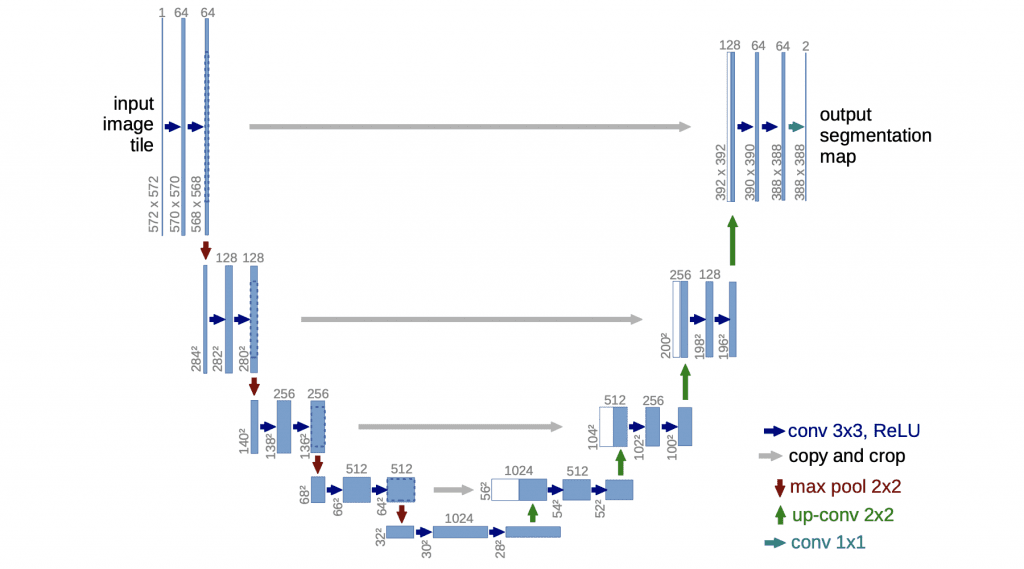

In [9]:
def double_conv_block(inputs, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x
def Build_Unet_Model(num_filters=64,input_shape=(256,256,1)):
    inputs = Input(input_shape)
    f_1 = double_conv_block(inputs, num_filters*1)
    p_1 = MaxPool2D((2, 2))(f_1)
    f_2 = double_conv_block(p_1, num_filters*2)
    p_2 = MaxPool2D((2, 2))(f_2)
    f_3 = double_conv_block(p_2, num_filters*4)
    p_3 = MaxPool2D((2, 2))(f_3)
    f_4 = double_conv_block(p_3, num_filters*8)
    p_4 = MaxPool2D((2, 2))(f_4)
    
    c=double_conv_block(p_4,num_filters*16)
    
    d_1 = Conv2DTranspose(num_filters*8, 2, strides=2, padding="same")(c)
    d_1= Concatenate()([d_1, f_4])
    d_1 = double_conv_block(d_1, num_filters*8) 
    
    d_2 = Conv2DTranspose(num_filters*4, 2, strides=2, padding="same")(d_1)
    d_2= Concatenate()([d_2, f_3])
    d_2 = double_conv_block(d_2, num_filters*4)  
    
    d_3 = Conv2DTranspose(num_filters*2, 2, strides=2, padding="same")(d_2)
    d_3= Concatenate()([d_3, f_2])
    d_3 = double_conv_block(d_3, num_filters*2)   
    
    d_4 = Conv2DTranspose(num_filters*1, 2, strides=2, padding="same")(d_3)
    d_4= Concatenate()([d_4, f_1])
    d_4 = double_conv_block(d_4, num_filters*1)    
    
    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d_4)
    Unet_Model = Model(inputs, outputs, name="UNetModel")
    return Unet_Model

In [10]:
Unet_Model = Build_Unet_Model()
Unet_Model.summary()



Model: "UNetModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 64)         640       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 64)         256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 256, 256, 64)         0         ['batch_normalizatio

In [4]:
def Dice_Coefficient(y_true, y_pred, smooth=1):
    intersection = K.sum(y_true * y_pred, axis=[1,2,3])
    union = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3])
    dice = K.mean((2.0 * intersection + smooth)/(union + smooth), axis=0)
    return dice

def Dice_Loss(y_true, y_pred):
    return 1.0 - Dice_Coefficient(y_true, y_pred)

In [12]:
Unet_Model.compile(loss=Dice_Loss , optimizer='adam', metrics=[Dice_Coefficient,"binary_accuracy"])

# time to train the Model

In [27]:
epochs = 20
Unet_Model.fit(x_train, y_train, epochs=epochs,batch_size=16,verbose=1,validation_data=validation_dataset)

Epoch 1/20
90/90 [==============================] - 2698s 30s/step - loss: 0.5266 - Dice_Coefficient: 0.4735 - binary_accuracy: 0.5571 - val_loss: 0.5673 - val_Dice_Coefficient: 0.4333 - val_binary_accuracy: 0.4971
Epoch 2/20
90/90 [==============================] - 3215s 36s/step - loss: 0.5132 - Dice_Coefficient: 0.4872 - binary_accuracy: 0.5606 - val_loss: 0.5614 - val_Dice_Coefficient: 0.4330 - val_binary_accuracy: 0.4758
Epoch 3/20
90/90 [==============================] - 2705s 30s/step - loss: 0.5029 - Dice_Coefficient: 0.4968 - binary_accuracy: 0.5682 - val_loss: 0.5360 - val_Dice_Coefficient: 0.4615 - val_binary_accuracy: 0.5072
Epoch 4/20
90/90 [==============================] - 3044s 34s/step - loss: 0.4943 - Dice_Coefficient: 0.5053 - binary_accuracy: 0.5678 - val_loss: 0.5983 - val_Dice_Coefficient: 0.4040 - val_binary_accuracy: 0.4888
Epoch 5/20
90/90 [==============================] - 3384s 37s/step - loss: 0.4849 - Dice_Coefficient: 0.5149 - binary_accuracy: 0.5708 - val

# saving the model

In [28]:
Unet_Model.save('segmetation_parham.h5')

c:\Users\zayna\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
Unet_Model.save('C:/Users/zayna/Desktop/segmetation_parham.h5')

# loading model

In [5]:
Unet_Model = load_model('segmetation_parham.h5', custom_objects={'Dice_Loss':                   
Dice_Loss,'Dice_Coefficient':Dice_Coefficient})

In [6]:
print(type(Unet_Model))

<class 'keras.src.engine.functional.Functional'>


# Visualizing the output

1/1 [==============================] - 0s 234ms/step


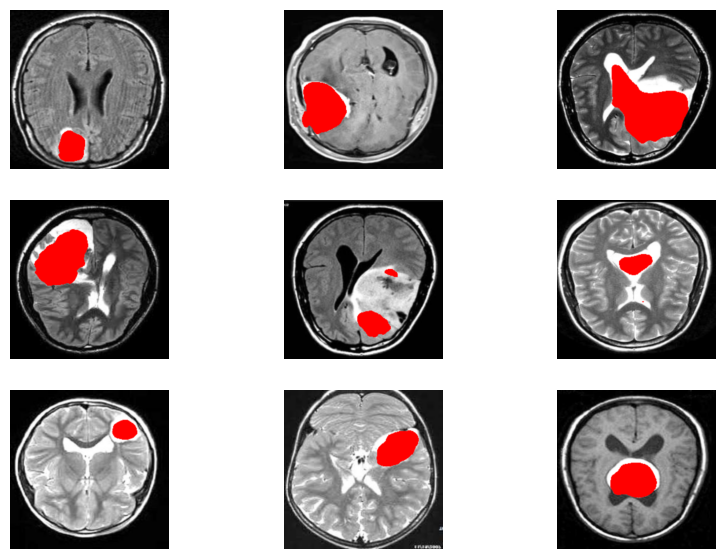

In [8]:
def threshold(array):
    array=array.flatten()
    flat_array=list(map(lambda x :255 if x>0.5 else 0,array))
    flat_array=np.array(flat_array)
    th=flat_array.reshape(256,256)
    return th 
def combine_pred_original(path,dir_path=False,plot=False):
    if dir_path==False : 
        image=cv.imread(path)
        image=cv.resize(image,(256,256))

        image_gray=cv.cvtColor(image,cv.COLOR_BGR2GRAY)

        image_1=image_gray / 255.0
        image_1= image_1.astype(np.float32)
        # plt.imshow(image,cmap='gray')

        image_1=image_1.reshape(-1,256,256,1)
        y_hat = Unet_Model.predict(image_1)

        y_hat=y_hat.reshape(256,256)
        mask=threshold(y_hat)
        finall_img=np.copy(image)
        index_mask=np.where(mask==255)
        finall_img[index_mask]=[0,0,255]
        finall_img=cv.resize(finall_img,(512,512))
        if plot==True : 
            plt.imshow(finall_img[:,:,::-1])
        return finall_img
    #     plt.imshow(image_gray,cmap='gray')
        
    else  :
        all_result={}
        all_img_name=os.listdir(path)
        image_count=len(all_img_name)
        if plot==True :
            rows,columns=3,ceil(image_count/3)
            fig = plt.figure(figsize=(10, 7))
        for c,name in enumerate(all_img_name) : 
            image=cv.imread(path+'/'+name)
            image=cv.resize(image,(256,256))

            image_gray=cv.cvtColor(image,cv.COLOR_BGR2GRAY)

            image_1=image_gray / 255.0
            image_1= image_1.astype(np.float32)
        # plt.imshow(image,cmap='gray')

            image_1=image_1.reshape(-1,256,256,1)
            y_hat = Unet_Model.predict(image_1)

            y_hat=y_hat.reshape(256,256)
            mask=threshold(y_hat)
            finall_img=np.copy(image)
            index_mask=np.where(mask==255)
            finall_img[index_mask]=[0,0,255]
            finall_img=cv.resize(finall_img,(512,512))
            all_result.update({name:finall_img})
            if plot==True :
                fig.add_subplot(rows, columns, c+1)
                plt.imshow(finall_img[:,:,::-1])
    
                plt.axis('off')
            
        return all_result
    
    

a = combine_pred_original(path=r'C:/Users/zayna/Desktop/Input/tumor/', dir_path=True, plot=True)


In [14]:
csv=pd.read_csv('my_segmentation_log_6.csv')

accuracy=csv['Dice_Coefficient']
val_accuracy=csv['val_Dice_Coefficient']
loss=csv['loss']
val_loss=csv['val_loss']

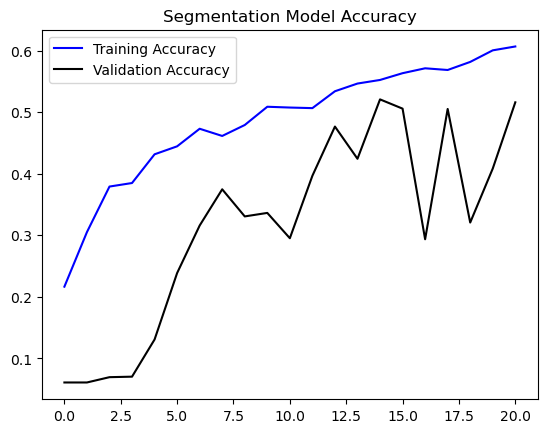

In [15]:
plt.plot(accuracy,label='Training Accuracy',color='blue')
plt.plot(val_accuracy,label='Validation Accuracy',color='black')
plt.legend()
plt.title('Segmentation Model Accuracy')
plt.show()


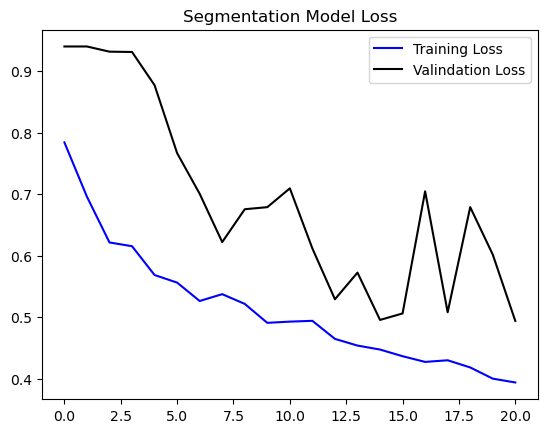

In [16]:
plt.plot(loss,label='Training Loss',color='blue')
plt.plot(val_loss,label='Valindation Loss',color='black')
plt.legend()
plt.title('Segmentation Model Loss')
plt.show()